In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import os

import warnings 
warnings.filterwarnings("ignore")

from matplotlib import pyplot as plt
from wordcloud import WordCloud,STOPWORDS
from sklearn.model_selection import train_test_split


from keras.models import Sequential
from keras.layers import Dense,LSTM,Embedding,GlobalAveragePooling1D

In [37]:
from keras.optimizers import Adam

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [17]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df  = pd.read_csv(r"D:\[Adv]deep_learning\nlp_project\fake_job_postings.csv\fake_job_postings.csv")

In [4]:
df.head(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [5]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
df.info()

In [6]:
df = df.drop(['job_id', 'title', 'location', 'department', 
              'salary_range','telecommuting', 'has_company_logo', 
              'has_questions', 'employment_type','required_experience', 
              'required_education', 'industry', 'function'],axis = 1)


In [7]:
df

,company_profile,description,requirements,benefits,fraudulent
0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0
1,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0
2,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0
3,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0
4,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0
...,...,...,...,...,...
17875,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0
17876,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0
17877,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0
17878,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company_profile  14572 non-null  object
 1   description      17879 non-null  object
 2   requirements     15184 non-null  object
 3   benefits         10668 non-null  object
 4   fraudulent       17880 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 698.6+ KB


In [9]:
df

,company_profile,description,requirements,benefits,fraudulent
0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0
1,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0
2,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0
3,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0
4,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0
...,...,...,...,...,...
17875,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0
17876,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0
17877,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0
17878,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0


In [10]:
df = df.fillna(" ")

In [11]:
df['description'] = df['description'] + " " + df["company_profile"] + " " + df["requirements"] + " " +df["benefits"]

In [12]:
df.head()

,company_profile,description,requirements,benefits,fraudulent
0,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0
1,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0
2,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0
3,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0
4,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0


In [13]:
df.columns

Index(['company_profile', 'description', 'requirements', 'benefits',
       'fraudulent'],
      dtype='object')

In [14]:
df = df.drop(['company_profile', 'requirements','benefits'],axis =1)

In [15]:
df

,description,fraudulent
0,"Food52, a fast-growing, James Beard Award-winn...",0
1,Organised - Focused - Vibrant - Awesome!Do you...,0
2,"Our client, located in Houston, is actively se...",0
3,THE COMPANY: ESRI – Environmental Systems Rese...,0
4,JOB TITLE: Itemization Review ManagerLOCATION:...,0
...,...,...
17875,Just in case this is the first time you’ve vis...,0
17876,The Payroll Accountant will focus primarily on...,0
17877,Experienced Project Cost Control Staff Enginee...,0
17878,Nemsia Studios is looking for an experienced v...,0


In [19]:
stopwords = set(STOPWORDS)
wcf = WordCloud(background_color = 'white',max_words = 2000,
                stopwords = stopwords )

wcf.generate(" ".join(df['description']))

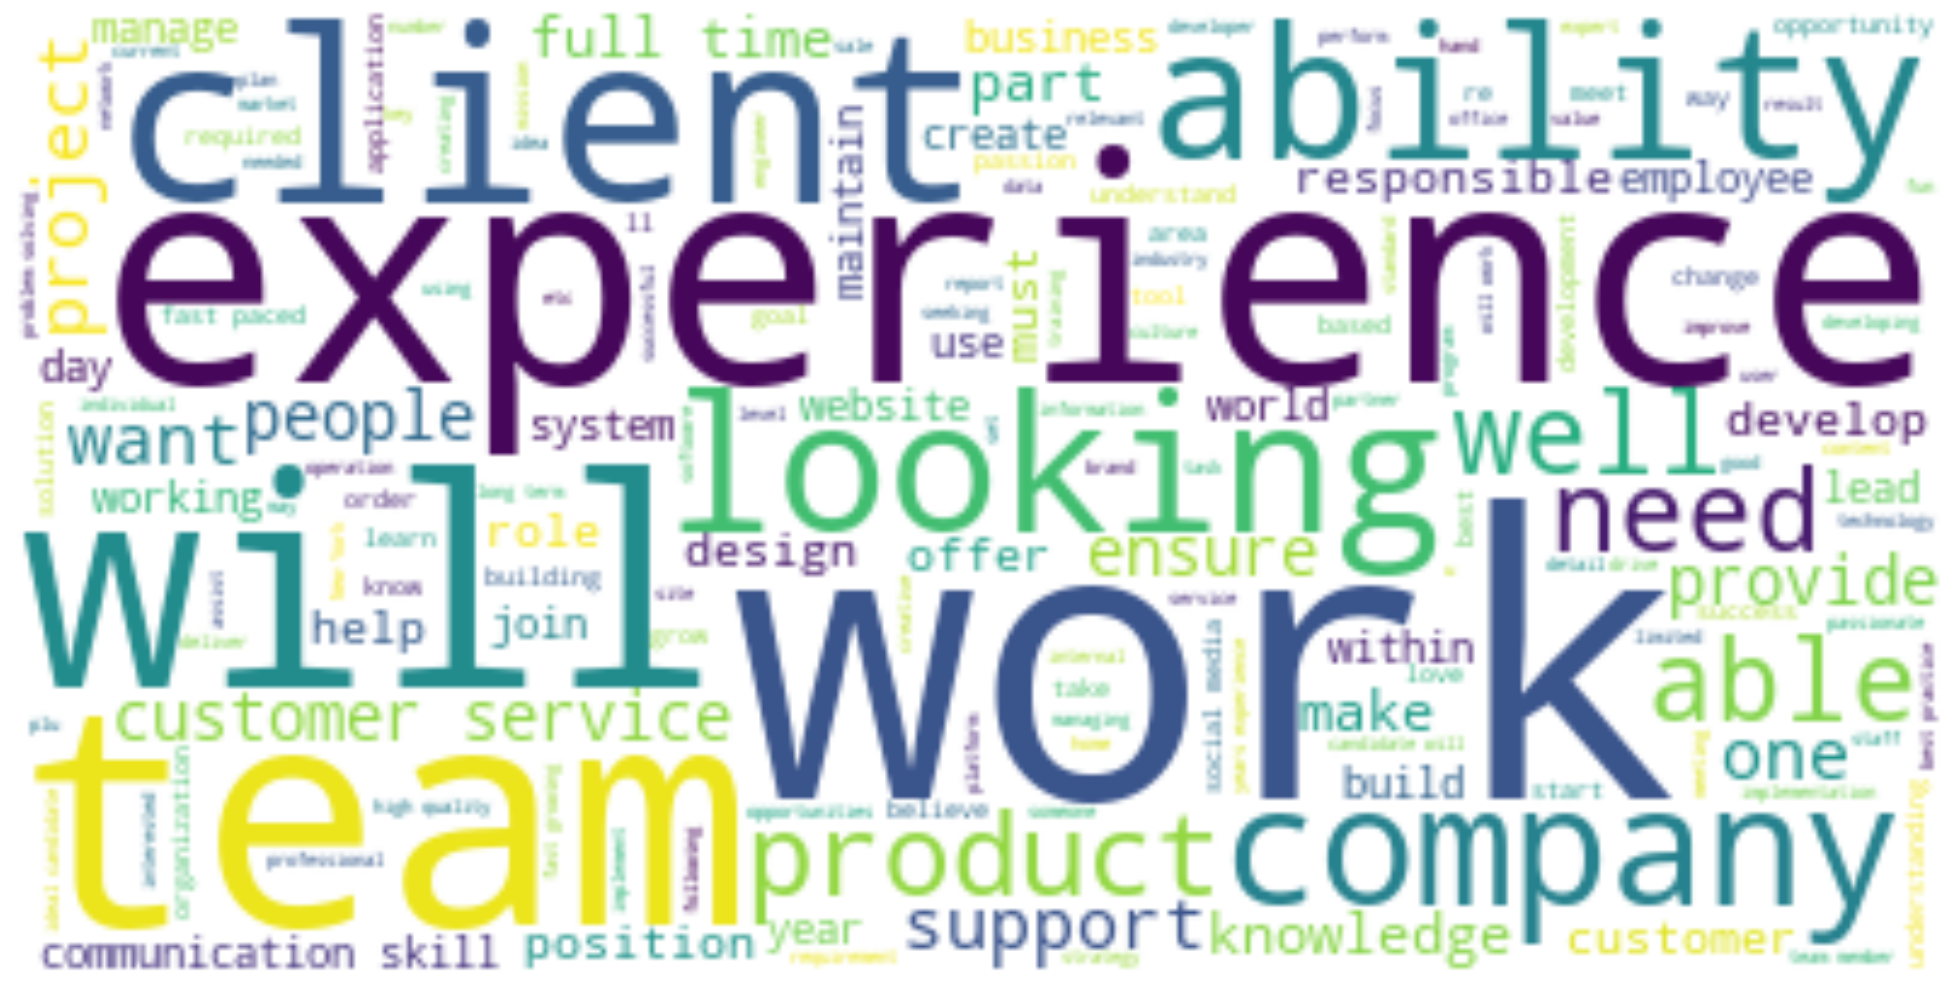

In [20]:
fig = plt.figure()
fig.set_figwidth(25)
fig.set_figheight(20)
plt.imshow(wcf,interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [21]:
df.fraudulent.value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [22]:
df.columns

Index(['description', 'fraudulent'], dtype='object')

In [23]:
X=df.description.astype('str')
y=df.fraudulent

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [29]:
vocab=3000
tokenizer=Tokenizer(vocab,oov_token="<oov>")

In [30]:
tokenizer.fit_on_texts(X_train)

In [31]:
train_sequence=tokenizer.texts_to_sequences(X_train)
test_sequence=tokenizer.texts_to_sequences(X_test)

In [32]:
padded_train=pad_sequences(train_sequence,maxlen=1500)
padded_test=pad_sequences(test_sequence,maxlen=1500)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Input

model = Sequential([
    Input(shape=(1500,)),   
    Embedding(input_dim=10000, output_dim=16),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [50]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 1500, 16)       │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,305 (634.00 KB)

 Trainable params: 162,305 (634.00 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.fit(padded_train,y_train,
          validation_data=(padded_test,y_test),epochs=10)

Epoch 1/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9760 - loss: 0.0694 - val_accuracy: 0.9676 - val_loss: 0.0866
Epoch 2/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9787 - loss: 0.0626 - val_accuracy: 0.9787 - val_loss: 0.0649
Epoch 3/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.9769 - loss: 0.0638 - val_accuracy: 0.9813 - val_loss: 0.0579
Epoch 4/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9783 - loss: 0.0640 - val_accuracy: 0.9706 - val_loss: 0.0830
Epoch 5/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9762 - loss: 0.0616 - val_accuracy: 0.9804 - val_loss: 0.0592
Epoch 6/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.9780 - loss: 0.0600 - val_accuracy: 0.9824 - val_loss: 0.0583
Epoch 7/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9763 - loss: 0.0685 - val_accuracy: 0.9522 - val_loss: 0.1163
Epoch 8/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9778 - loss: 0.0659 - v

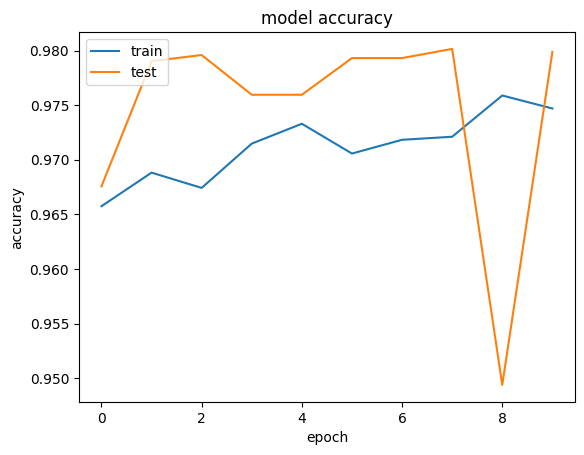

In [55]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [65]:
print(type(X_test))
print(type(y_test))

print(X_test.dtype)
print(y_test.dtype)

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
object
int64


In [66]:
X_test = np.array(X_test)

In [57]:
df["description"][0]

"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.Reproducing and/or repackaging existing Food52 content for a number of partner sites, such as Huffington Post, Yahoo, Buzzfeed, and more in their various content management systemsResearching blogs and websites for the Provisions by Food52 Affiliate ProgramAssisting in day-to-day affiliate program support, such as screening affiliates and assisting in any affiliate inquiriesSupporting with PR &amp; Events when neededHelping with office administrative work, such as filing, mailing, and preparing for meetingsWorking with developers to document bugs and suggest improvements to the siteSupporting the marketing and executive staff We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, 

In [58]:
job_post = ["Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.Reproducing and/or repackaging existing Food52 content for a number of partner sites, such as Huffington Post, Yahoo, Buzzfeed, and more in their various content management systemsResearching blogs and websites for the Provisions by Food52 Affiliate ProgramAssisting in day-to-day affiliate program support, such as screening affiliates and assisting in any affiliate inquiriesSupporting with PR &amp; Events when neededHelping with office administrative work, such as filing, mailing, and preparing for meetingsWorking with developers to document bugs and suggest improvements to the siteSupporting the marketing and executive staff We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Experience with content management systems a major plus (any blogging counts!)Familiar with the Food52 editorial voice and aestheticLoves food, appreciates the importance of home cooking and cooking with the seasonsMeticulous editor, perfectionist, obsessive attention to detail, maddened by typos and broken links, delighted by finding and fixing themCheerful under pressureExcellent communication skillsA+ multi-tasker and juggler of responsibilities big and smallInterested in and engaged with social media like Twitter, Facebook, and PinterestLoves problem-solving and collaborating to drive Food52 forwardThinks big picture but pitches in on the nitty gritty of running a small company (dishes, shopping, administrative support)Comfortable with the realities of working for a startup: being on call on evenings and weekends, and working long hours  "]

In [68]:
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [69]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_test_pad = pad_sequences(X_test_seq, maxlen=1500)

In [72]:
model.evaluate(X_test_pad, y_test)

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9818 - loss: 0.0549


[0.05490643531084061, 0.9818232655525208]

In [73]:
seq = tokenizer.texts_to_sequences(job_post)
pad = pad_sequences(seq, maxlen=1500)

prediction = model.predict(pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
[[0.00140549]]


In [74]:
prediction = model.predict(pad)

if prediction[0][0] >= 0.5:
    print("Fake Job Post")
else:
    print("Real Job Post")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Real Job Post
